# 07 Google otoc example


Build `U`, then `U dagger`, and verify return to the initial state. This is the basic Loschmidt echo idea.

Information scrambling is when a initilized/local state has its uncertanty increased deu to the spread of its information into more states/ degrees of freedom. The spread comes from a butterfly operator $O(t) = U^\dagger O U$. 

We can write in a certain basis $\{B_j = P_i \otimes P_i \dots \}$: $O = \sum_j^{n_p} \omega_j B_j$, then we can understand $\bold{\text{operator entanglement}}$ as many significant participation on $\omega_n$. $\bold{\text{operator spreading}}$ is related to how many non-identity Pauli are in $B_j$  

#### Out-of-time order correlator (OTOC)

Here defined as 
$$C(t) =  \langle O(t)M O(t) M \rangle $$
where $M$ is the measurement qubit, for examplem $M = Z_1$. At $t = 0$, since M and O(t=0) are in different qubit, O and M commute and C(t =0) = 1. 

In general, O(t) spreads and can become a string like $O(t) = \sqrt(0.75) Z_2 + \sqrt(0.25) X_1X_2$, then $X_1Z_1 = - Z_1 X_1$. Finally, C(t) in this example becomes $C(t) = 0.75*(1)  + (0.25)*(-1) = 0.5$.

Finally, in a fully scrambled O(t), we will have a mixture of many Pauli strings, each commuting or anticommuting with M. The contributions become basically balanced in which $C(t) \to 0$. 

Analyzis:

1. Measure C(t) with the number of cycles (time), as more time we enable the system to evolve more information spreading.

2. Measure C(t) for different butterfly qubits. If qubits are closer to the measurement qubit, C(t) decays faster. 

3. What is the effect of different buterfly op. X, Y, or Z. Identity is just a renormalization procedure. 
    

#### How the OTOC C(t) is performed in the quantum circuit?

The idea comes from using qubits and the ancilla as a interfemoter experiment. 
    
1. Preparing qubits at $|+X\rangle$ ($q_1$ becomes sensitive to $M = Z_1$) and acilla at $|+Y\rangle$

2. CZ between Measurement qubit $q_1$ and ancilla $q_a$:
$$|\psi\rangle=  CZ |+Y\rangle|+X\rangle  = \frac{1}{\sqrt{2}} CZ (|0\rangle + i |1\rangle) |+X\rangle =  \frac{1}{\sqrt{2}}|0\rangle|+X\rangle + i|1\rangle M|+X\rangle $$

3. Butterly evolution: Define $U$ from random 1qubit gates and CZs as EG and O as a Pauli. We then perform $U^\dagger O U = O(t)$ on the qubits an another CZ between $q_1$ and $q_a$
$$|\psi\rangle =  \frac{1}{\sqrt{2}}|0\rangle O(t)|+X\rangle + i|1\rangle MO(t)M|+X\rangle = \frac{1}{\sqrt{2}}|0\rangle |\alpha\rangle + i|1\rangle |\beta\rangle$$
then, rewritting in Y basis $|\pm Y\rangle = \frac{1}{\sqrt{2}} (|0\rangle \pm i|1\rangle)$
$$|\psi\rangle = \frac{1}{\sqrt{2}} \Big[|+Y\rangle (| \alpha \rangle +| \beta \rangle) + |-Y\rangle (| \alpha \rangle - | \beta \rangle)\Big]$$
So,
$P(+Y) = \frac{1}{4}\Big( 2 + 2Re(\langle \alpha| \beta \rangle) \Big)$ and 
$P(-Y) = \frac{1}{4}\Big( 2 - 2Re(\langle \alpha| \beta \rangle) \Big)$

Finaly, $\langle Y \rangle = P(+Y) - P(-Y) = Re(\langle \alpha| \beta \rangle) = Re \Big( \langle +X|O^{\dagger}(t) MO(t)M |+X\rangle \Big)$

$\langle Y \rangle = Re \Big( \langle +X|O^{\dagger}(t) MO(t)M |+X\rangle \Big) = C(t)$

4. We need to measure $\langle Y \rangle$ instead of usual Z in the circuit. For that we just apply $X^{0.5}$ ($\pi/2$ rotation in X), 
because $X^{0.5} |+Y\rangle = |0\rangle$ and $X^{0.5} |-Y\rangle = |1\rangle$. Therefore, we can safely measure Z and get $\langle Y \rangle$ by $P(0) - P(1)$   

$q_a = |\pm Y\rangle $ and when step 4. to rotate to Z and measure $X^{\pm 0.5}$. We have 4 combinations $\{(|+ Y\rangle, X^{+ 0.5}), (|+ Y\rangle, X^{- 0.5}), (|- Y\rangle, X^{+ 0.5}), (|- Y\rangle, X^{- 0.5})  \}$

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
import cirq_google as cg
from recirq import otoc

Google code for using or not a noise simulator

In [ ]:
print("The noise simulator used in the example does not exist anymore.")
print("I will build a similar noise model which replaces \n fSim/iSWAP-like gates by Gaussian-random PhasedFSim gates." )

#https://quantumai.google/reference/python/cirq/FSimGate
print("FSimGate(θ, φ) = ISWAP**(-2θ/π) CZPowGate(exponent=-φ/π)")

# Same sigmas as the old Google tutorial.
PHASED_FSIM_SIGMA = {
    "theta": 0.01, #random error in the iSWAP
    "zeta": 0.10, # larger single qubit phase errors
    "gamma": 0.10, # larger single qubit phase errors
    "chi": 0.01, #phase parameter
    "phi": 0.02, #controlled-phase error
}

rng = np.random.default_rng(seed=1234)


def _is_iswap_pow_gate(gate):
    """Return True if gate is an ISwapPowGate"""
    return isinstance(gate, cirq.ISwapPowGate)


def _phased_fsim_mean_from_gate(gate):
    """Return PhasedFSim mean parameters for common two-qubit gates.

    For sqrt_iSWAP^{-1}, Cirq's convention gives theta = pi/4.
    The relation is:
        FSim(theta, phi) = ISWAP**(-2 theta / pi) * CZPowGate(exponent=-phi/pi)
    """
    if isinstance(gate, cirq.PhasedFSimGate):
        return {
            "theta": float(gate.theta),
            "zeta": float(gate.zeta),
            "chi": float(gate.chi),
            "gamma": float(gate.gamma),
            "phi": float(gate.phi),
        }

    if isinstance(gate, cirq.FSimGate):
        return {
            "theta": float(gate.theta),
            "zeta": 0.0,
            "chi": 0.0,
            "gamma": 0.0,
            "phi": float(gate.phi),
        }

    if _is_iswap_pow_gate(gate):
        exponent = float(gate.exponent)
        theta = -np.pi * exponent / 2.0
        return {
            "theta": theta,
            "zeta": 0.0,
            "chi": 0.0,
            "gamma": 0.0,
            "phi": 0.0,
        }
    
    #if something else, does nothing
    return None


def randomize_sqrt_iswap_like_gates(circuit, rng):
    """Replace fSim/iSWAP-like two-qubit gates by Gaussian-random PhasedFSim gates.
        input: circuit
        output: new circuit with randomized gates
    """
    new_circuit = cirq.Circuit()

    #circuit.moments list
    for moment in circuit:
        new_ops = []

        #moment is a list of operations
        for op in moment.operations:
            gate = op.gate #getting gate from op

            #if I or not a 2 qubit gate, do nothing
            if gate is None or len(op.qubits) != 2:
                new_ops.append(op)
                continue

            # identify if it is a phased-fsim gate
            mean = _phased_fsim_mean_from_gate(gate)

            if mean is None:
                new_ops.append(op)
                continue

            sampled = {
                key: rng.normal(loc=mean[key], scale=PHASED_FSIM_SIGMA[key])
                for key in mean
            }

            noisy_gate = cirq.PhasedFSimGate(**sampled)
            new_ops.append(noisy_gate.on(*op.qubits))

        new_circuit.append(cirq.Moment(new_ops))

    return new_circuit


def randomize_sqrt_iswap_like_circuit_list(circuits, rng):
    """Apply randomize_sqrt_iswap_like_gates to each circuit in a list.

    Args:
        circuits: list of cirq.Circuit objects.
        rng: numpy random generator, e.g. np.random.default_rng(1234).

    Returns:
        list of randomized cirq.Circuit objects.
    """
    randomized_circuits = []

    for circuit in circuits:
        randomized_circuit = randomize_sqrt_iswap_like_gates(circuit, rng)
        randomized_circuits.append(randomized_circuit)

    return randomized_circuits

The noise simulator used in the example does not exist anymore.
I will build a similar noise model which replaces 
 fSim/iSWAP-like gates by Gaussian-random PhasedFSim gates.
FSimGate(θ, φ) = ISWAP**(-2θ/π) CZPowGate(exponent=-φ/π)


In [6]:
import os

# The Google Cloud Project id to use.
project_id = ''


use_noisy_simulator = False
if project_id == '' and 'GOOGLE_CLOUD_PROJECT' not in os.environ:
    print("No project_id provided and environment variable "
          "GOOGLE_CLOUD_PROJECT not set.")
    use_noisy_simulator = True
else: 
    os.environ['GOOGLE_CLOUD_PROJECT'] = project_id

    def authenticate_user():
        """Runs the user through the Colab OAuth process.

        Checks for Google Application Default Credentials and runs interactive login 
        if the notebook is executed in Colab. In case the notebook is executed in Jupyter notebook
        or other IPython runtimes, no interactive login is provided, it is assumed that the 
        `GOOGLE_APPLICATION_CREDENTIALS` env var is set or `gcloud auth application-default login`
        was executed already.

        For more information on using Application Default Credentials see 
        https://cloud.google.com/docs/authentication/production
        """
        in_colab = False
        try:
            from IPython import get_ipython
            in_colab = 'google.colab' in str(get_ipython())
        except: 
            # Notebook is not executed within IPython. Assuming external authentication.
            return 

        if in_colab: 
            from google.colab import auth      
            print("Getting OAuth2 credentials.")
            print("Press enter after entering the verification code.")
            auth.authenticate_user(clear_output=False)
            print("Authentication complete.")
        else: 
            print("Notebook is not executed with Colab, assuming Application Default Credentials are setup.") 

    authenticate_user()
    print("Successful authentication to Google Cloud.")

processor_id = ""
use_noisy_simulator = use_noisy_simulator or processor_id == "" 
if use_noisy_simulator:
    print("Using a noisy simulator.")
    print("Using custom Gaussian PhasedFSim noisy simulator.")
    sampler = cirq.Simulator(seed=1234)
    device = cg.Sycamore
else:
    sampler = cg.get_engine_sampler(processor_id, gate_set_name="sqrt_iswap")
    device = cg.get_engine_device(processor_id=processor_id)


No project_id provided and environment variable GOOGLE_CLOUD_PROJECT not set.
Using a noisy simulator.
Using custom Gaussian PhasedFSim noisy simulator.


In [7]:
print("Finding a good line of qubits to run in the real device \n")
use_noisy_simulator=True
if not use_noisy_simulator:
    calibration = cg.get_engine_calibration(processor_id=processor_id)
    calibration_heatmap(key="two_qubit_sycamore_gate_xeb_average_error_per_cycle").plot()
else:
    print("Using a noisy simulator, so using a possible return from calibration")
    qubit_indices = [(4, 1), (4, 2), (5, 2), (5, 3), (6, 3), (7, 3), (7, 4), (7, 5)]
    ancilla_index = (5, 1)

Finding a good line of qubits to run in the real device 

Using a noisy simulator, so using a possible return from calibration


In [8]:
print("Defining qubits and ancilla")
qubits=[cirq.GridQubit(x,y) for x,y in qubit_indices]
print(f"qubits = {qubits}")
ancilla=cirq.GridQubit(*ancilla_index)
print(f"ancilla = {ancilla}")
num_qubits= len(qubits)

Defining qubits and ancilla
qubits = [cirq.GridQubit(4, 1), cirq.GridQubit(4, 2), cirq.GridQubit(5, 2), cirq.GridQubit(5, 3), cirq.GridQubit(6, 3), cirq.GridQubit(7, 3), cirq.GridQubit(7, 4), cirq.GridQubit(7, 5)]
ancilla = q(5, 1)


In [9]:
print("In a 1D chain we have two layers of 2Q gates, even-odd and odd-even")
print("Because (q1,q2) and (q2,q3) cannot be applied simultaneously" )
int_sets = [
    {(qubits[i], qubits[i+1]) for i in range(0,num_qubits-1,2)},
    {(qubits[i], qubits[i+1]) for i in range(1,num_qubits-1,2)}
    ]
print(int_sets)

print("Building foward evolution with CZ gates")

forward_ops = {
   (qubit_indices[j], qubit_indices[j+1]): cirq.Circuit([cirq.CZ(qubits[j], qubits[j+1])]) for j in range(num_qubits-1)
    }
reverse_ops = forward_ops.copy() # because CZ^\dagger is CZ


In a 1D chain we have two layers of 2Q gates, even-odd and odd-even
Because (q1,q2) and (q2,q3) cannot be applied simultaneously
[{(cirq.GridQubit(7, 4), cirq.GridQubit(7, 5)), (cirq.GridQubit(5, 2), cirq.GridQubit(5, 3)), (cirq.GridQubit(4, 1), cirq.GridQubit(4, 2)), (cirq.GridQubit(6, 3), cirq.GridQubit(7, 3))}, {(cirq.GridQubit(5, 3), cirq.GridQubit(6, 3)), (cirq.GridQubit(4, 2), cirq.GridQubit(5, 2)), (cirq.GridQubit(7, 3), cirq.GridQubit(7, 4))}]
Building foward evolution with CZ gates


In [63]:
print("We define number of trials for averaging")
num_trials = 4
cycles = range(0, 20+1, 2) #number of cycles gives the time

We define number of trials for averaging


### Running an example for just a cycle = 2 of one butterfly qubit

In [81]:
# Example number of cycles and butterfly qubit.
cycle = cycles[1]
q_b = qubits[2]

otoc_circuits = otoc.build_otoc_circuits(
    qubits,
    ancilla,
    cycle,
    int_sets,
    forward_ops=forward_ops,
    reverse_ops=reverse_ops,
    butterfly_qubits=q_b,
    cycles_per_echo=2,
    sq_gates=np.random.choice(8, (num_qubits, max(cycles))),
    use_physical_cz=True,
)

In [91]:
print("Ancilla qubit:", ancilla)
print("Measurement qubit:", qubits[0])
print("Butterfly qubit:", q_b)

print("\nExample OTOC circuit:\n")
display(otoc_circuits.butterfly_Y) #change X,Y,Z,I for different buterfly op. 

Ancilla qubit: q(5, 1)
Measurement qubit: q(4, 1)
Butterfly qubit: q(5, 2)

Example OTOC circuit:



[(4, 1): ───Y^0.5────────@───Y^0.5────────────@───PhX(0.75)^0.5───────────────PhX(-0.25)^0.5───@───Y^-0.5───────────@─────────────────────────
                        │                    │                                                │                    │
(4, 2): ───Y^0.5────────┼───PhX(-0.25)^0.5───@───PhX(0.75)^0.5───@───────@───PhX(-0.25)^0.5───@───PhX(0.75)^0.5────┼─────────────────────────
                        │                                        │       │                                         │
(5, 1): ───PhX(0)^0.5───@────────────────────────Y───────────────┼───────┼───Y─────────────────────────────────────@───PhX(0)^0.5───M('z')───
                                                                 │       │
(5, 2): ───Y^0.5────────────X^-0.5───────────@───Y^0.5───────────@───Y───@───Y^-0.5───────────@───X^0.5──────────────────────────────────────
                                             │                                                │
(5, 3): ───Y^0.5──────────

In [80]:
circuit_otoc_optimized = cirq.optimize_for_target_gateset(
    otoc_circuits.butterfly_I[2],
    gateset=cg.SycamoreTargetGateset(),
)
print(circuit_otoc_optimized)

(4, 1): ───PhXZ(a=0.707,x=0.109,z=0.0772)───SYC───PhXZ(a=0.0677,x=1,z=0)───────SYC───PhXZ(a=-0.325,x=0.396,z=0.348)───────SYC────────────────────────────────SYC───PhXZ(a=0.333,x=0.261,z=0.797)───────────────────────────────────────────────PhXZ(a=-1.11e-16,x=0.586,z=0.0833)───SYC────────────────────────────────SYC───PhXZ(a=0.917,x=0.414,z=-0.917)─────────────────────────────────────────────PhXZ(a=-1.11e-16,x=0.586,z=0.0833)───SYC────────────────────────────────SYC───PhXZ(a=0.917,x=0.414,z=-0.417)─────────────────────────────────────────────PhXZ(a=-1.11e-16,x=0.586,z=0.0833)───SYC───────────────────────────SYC───PhXZ(a=-0.0833,x=0.0863,z=-0.917)────────────────────────────────────────────PhXZ(a=-1.11e-16,x=0.586,z=0.0833)───SYC────────────────────────────────SYC───PhXZ(a=0.917,x=0.164,z=0.833)───────────────────────────────────────────────PhXZ(a=0.568,x=0.586,z=0)─────────SYC───PhXZ(a=0.0677,x=1,z=0)───────SYC───PhXZ(a=-0.0444,x=0.325,z=0.896)────────────────────────────────────────────P

In [78]:
job = sampler.run(
            program=circuit_otoc_optimized, 
            repetitions=int(2_000),
        )
display(job.measurements["z"])
np.mean(job.measurements["z"])

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1), dtype=int8)

np.float64(0.0)

### Getting back to now many cicles and many trials

In [66]:

q_b = qubits[2]

for cycle in cycles:
        
    otoc_circuits = otoc.build_otoc_circuits(
        qubits,
        ancilla,
        cycle,
        int_sets,
        forward_ops=forward_ops,
        reverse_ops=reverse_ops,
        butterfly_qubits=q_b,
        cycles_per_echo=2,
        sq_gates=np.random.choice(8, (num_qubits, max(cycles))),
        use_physical_cz=True,
    )

In [67]:
np.random.seed(0)  # Random seed for OTOC circuits.

circuit_list = []
for i in range(num_trials):
    circuits_i = []

    for cycle in cycles:
        circuits_ic = []

        for k, q_b in enumerate(qubits[1:]):
            circs = otoc.build_otoc_circuits(
                qubits,
                ancilla,
                cycle,
                int_sets,
                forward_ops=forward_ops,
                reverse_ops=reverse_ops,
                butterfly_qubits=q_b,
                cycles_per_echo=2,
                sq_gates=np.random.choice(8, (num_qubits, max(cycles))),
                use_physical_cz=True,
            )

            # If q_b is the measurement qubit, add both the normalization 
            # circuits and the circuits with X as the butterfly operator. 
            # Otherwise only add circuits with Y being the butterfly operator.
            if k == 0:
                circuits_ic.extend(circs.butterfly_I)
                circuits_ic.extend(circs.butterfly_X)
            else:
                circuits_ic.extend(circs.butterfly_Y)
        circuits_i.append(circuits_ic)
    circuit_list.append(circuits_i)


In [68]:
# Compile to sqrt_iswap.
from tqdm import tqdm

progress = tqdm(total=np.array(circuit_list, dtype=object).size)
for i, circuits_trial in enumerate(circuit_list):
    for j, circuits_cycle in enumerate(circuits_trial):
        for k, circuit_otoc in enumerate(circuits_cycle):
            circuit_list[i][j][k] =  cirq.optimize_for_target_gateset(otoc_circuits.butterfly_Y[0],gateset=cg.SycamoreTargetGateset())
            progress.update()

100%|██████████| 352/352 [07:32<00:00,  1.29s/it]


In [69]:
results = []
for i, circuits_i in enumerate(circuit_list):
    results_i = np.zeros((num_qubits, len(cycles)))

    for c, circuits_ic in enumerate(circuits_i):
        print("\r", f"On trial {i + 1} / {num_trials}, cycle {c + 1} / {len(cycles)}.", end="")

        job = sampler.run_batch(
            programs=randomize_sqrt_iswap_like_circuit_list(circuits_ic, rng), 
            repetitions=int(2_000 + 10_000 * (c / max(cycles)) ** 3),
        )

        # Compute ⟨σ_y⟩ (or normalization ⟨I⟩).
        for d in range(num_qubits):
            p =  np.mean(job[4 * d    ][0].measurements["z"])
            p -= np.mean(job[4 * d + 1][0].measurements["z"])
            p -= np.mean(job[4 * d + 2][0].measurements["z"])
            p += np.mean(job[4 * d + 3][0].measurements["z"])
            results_i[d, c] = 0.5 * p
    results.append(results_i)


 On trial 4 / 4, cycle 11 / 11.

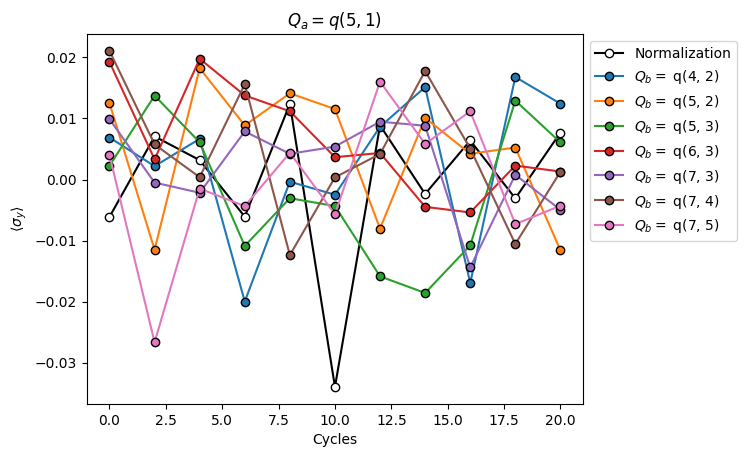

In [70]:
# Average the data for the `num_trials` random circuits.
results_ave = np.mean(results, axis=0)

# Plot the result with no butterfly operator.
plt.plot(cycles, results_ave[0, :], "o-", color="black", mec="black", mfc="white", label="Normalization")

# Plot results for each butterfly qubit.
for i in range(1, num_qubits):
    plt.plot(cycles, results_ave[i, :], "o-", mec="black", label="$Q_b =$ {}".format(qubits[i]))

plt.title(f"$Q_a = {ancilla}$")
plt.xlabel("Cycles")
plt.ylabel(r"$\langle \sigma_y \rangle$")
plt.legend(bbox_to_anchor=(1, 1));

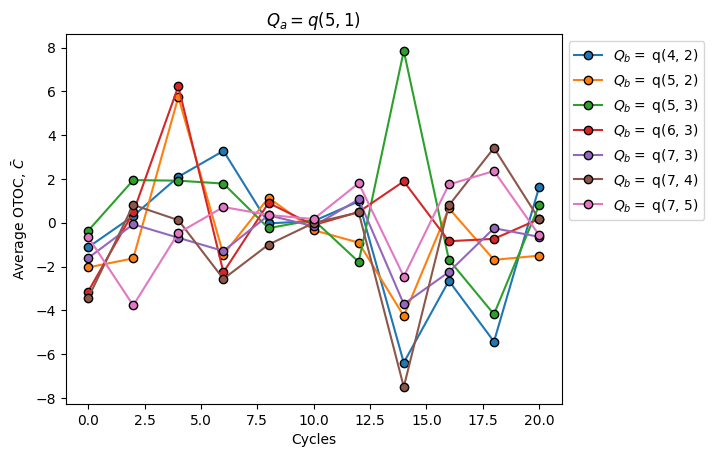

In [71]:
for i in range(1, num_qubits):
    plt.plot(cycles, results_ave[i, :] / results_ave[0, :], "o-", mec="black", label="$Q_b =$ {}".format(qubits[i]))

plt.title(f"$Q_a = {ancilla}$")
plt.xlabel("Cycles")
plt.ylabel(r"Average OTOC, $\bar{C}$")
plt.legend(bbox_to_anchor=(1, 1));